In [1]:
!pip install numpy pandas matplotlib scikit-learn statsmodels xgboost torch joblib

In [2]:
import os
import zipfile
import warnings
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
PROJECT_DIR = r"E:\MY projects\Flash Flood Prediction Project"

DATA_ZIP = os.path.join(
    PROJECT_DIR,
    "data",
    "Slope_monthly.zip"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "Slope"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Dataset:", DATA_ZIP)
print("Model directory:", MODEL_DIR)

Dataset: E:\MY projects\Flash Flood Prediction Project\data\Slope_monthly.zip
Model directory: E:\MY projects\Flash Flood Prediction Project\models\Slope


In [5]:
data_list = []
empty_files = []

with zipfile.ZipFile(DATA_ZIP, "r") as z:

    csv_files = [
        name for name in z.namelist()
        if name.lower().endswith(".csv")
    ]

    print(
        "CSV files found:",
        len(csv_files)
    )

    for file in csv_files:

        try:

            with z.open(file) as f:
                temp = pd.read_csv(f)

            if temp.empty:
                empty_files.append(file)
                continue

            data_list.append(temp)

        except Exception as e:

            print(
                "Error reading:",
                file
            )

            print(e)

print(
    "Valid files:",
    len(data_list)
)

print(
    "Empty files:",
    len(empty_files)
)

CSV files found: 80
Valid files: 80
Empty files: 0


In [6]:
df = pd.concat(
    data_list,
    ignore_index=True
)

print(
    "Dataset shape:",
    df.shape
)

display(df.head())

Dataset shape: (80, 5)


,year,month,slope_mean_degree,slope_min_degree,slope_max_degree
0,2020,1,35.282303,0,79.505859
1,2020,2,35.282303,0,79.505859
2,2020,3,35.282303,0,79.505859
3,2020,4,35.282303,0,79.505859
4,2020,5,35.282303,0,79.505859


In [7]:
df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

df["month"] = pd.to_numeric(
    df["month"],
    errors="coerce"
)

df["slope_mean_degree"] = pd.to_numeric(
    df["slope_mean_degree"],
    errors="coerce"
)

df["slope_min_degree"] = pd.to_numeric(
    df["slope_min_degree"],
    errors="coerce"
)

df["slope_max_degree"] = pd.to_numeric(
    df["slope_max_degree"],
    errors="coerce"
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna()

df = df.sort_values(
    ["year", "month"]
).reset_index(drop=True)

print(
    "Clean dataset:",
    df.shape
)

Clean dataset: (80, 5)


In [8]:
df["datetime"] = pd.to_datetime(
    df["year"].astype(int).astype(str)
    + "-"
    + df["month"].astype(int).astype(str)
    + "-01"
)

df = df.sort_values(
    "datetime"
).reset_index(drop=True)

display(df.head())
display(df.tail())

,year,month,slope_mean_degree,slope_min_degree,slope_max_degree,datetime
0,2020,1,35.282303,0,79.505859,2020-01-01
1,2020,2,35.282303,0,79.505859,2020-02-01
2,2020,3,35.282303,0,79.505859,2020-03-01
3,2020,4,35.282303,0,79.505859,2020-04-01
4,2020,5,35.282303,0,79.505859,2020-05-01


,year,month,slope_mean_degree,slope_min_degree,slope_max_degree,datetime
75,2026,4,35.282303,0,79.505859,2026-04-01
76,2026,5,35.282303,0,79.505859,2026-05-01
77,2026,6,35.282303,0,79.505859,2026-06-01
78,2026,7,35.282303,0,79.505859,2026-07-01
79,2026,8,35.282303,0,79.505859,2026-08-01


In [9]:
print(
    "Unique mean slope values:",
    df["slope_mean_degree"].nunique()
)

print(
    "\nStatistics:"
)

print(
    df["slope_mean_degree"].describe()
)

Unique mean slope values: 1

Statistics:
count    80.000000
mean     35.282303
std       0.000000
min      35.282303
25%      35.282303
50%      35.282303
75%      35.282303
max      35.282303
Name: slope_mean_degree, dtype: float64


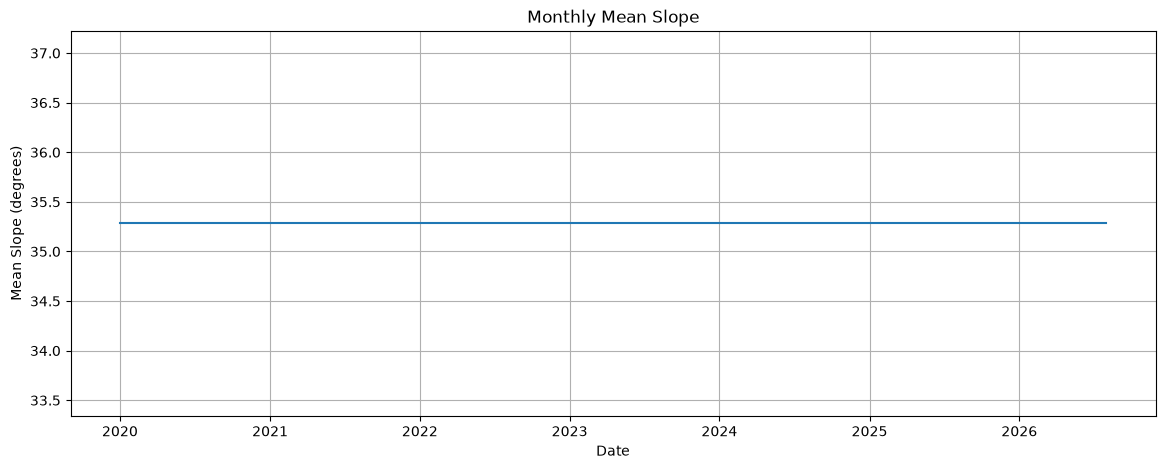

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["datetime"],
    df["slope_mean_degree"]
)

plt.xlabel("Date")
plt.ylabel("Mean Slope (degrees)")
plt.title("Monthly Mean Slope")

plt.grid(True)

plt.show()

In [11]:
series = df[
    ["datetime", "slope_mean_degree"]
].copy()

series = series.set_index(
    "datetime"
)

y = series[
    "slope_mean_degree"
].astype(float)

print(y.head())
print("\nSamples:", len(y))

datetime
2020-01-01    35.282303
2020-02-01    35.282303
2020-03-01    35.282303
2020-04-01    35.282303
2020-05-01    35.282303
Name: slope_mean_degree, dtype: float64

Samples: 80


In [12]:
print(
    "NaN:",
    y.isna().sum()
)

print(
    "Inf:",
    np.isinf(y).sum()
)

print(
    "Min:",
    y.min()
)

print(
    "Max:",
    y.max()
)

NaN: 0
Inf: 0
Min: 35.28230268143529
Max: 35.28230268143529


In [13]:
split_index = int(
    len(y) * 0.8
)

train = y.iloc[
    :split_index
]

test = y.iloc[
    split_index:
]

print(
    "Training samples:",
    len(train)
)

print(
    "Testing samples:",
    len(test)
)

Training samples: 64
Testing samples: 16


In [14]:
print("Training ARIMA...")

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_pred = np.asarray(
    arima_pred,
    dtype=float
)

arima_pred = np.nan_to_num(
    arima_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print(
    "ARIMA completed!"
)

Training ARIMA...
ARIMA completed!


In [15]:
print("Training SARIMAX...")

sarimax_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False
)

sarimax_pred = sarimax_fit.forecast(
    steps=len(test)
)

sarimax_pred = np.asarray(
    sarimax_pred,
    dtype=float
)

sarimax_pred = np.nan_to_num(
    sarimax_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print(
    "SARIMAX completed!"
)

Training SARIMAX...
SARIMAX completed!


In [16]:
xgb_df = pd.DataFrame({
    "value": y
})

for lag in [
    1,
    2,
    3,
    6,
    12
]:

    xgb_df[
        f"lag_{lag}"
    ] = xgb_df[
        "value"
    ].shift(lag)

xgb_df["month"] = (
    xgb_df.index.month
)

xgb_df["year"] = (
    xgb_df.index.year
)

xgb_df = xgb_df.dropna()

display(xgb_df.head())

,value,lag_1,lag_2,lag_3,lag_6,lag_12,month,year
datetime,,,,,,,,
2021-01-01,35.282303,35.282303,35.282303,35.282303,35.282303,35.282303,1,2021
2021-02-01,35.282303,35.282303,35.282303,35.282303,35.282303,35.282303,2,2021
2021-03-01,35.282303,35.282303,35.282303,35.282303,35.282303,35.282303,3,2021
2021-04-01,35.282303,35.282303,35.282303,35.282303,35.282303,35.282303,4,2021
2021-05-01,35.282303,35.282303,35.282303,35.282303,35.282303,35.282303,5,2021


In [17]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "month",
    "year"
]

X = xgb_df[features]

Y = xgb_df["value"]

In [18]:
xgb_split = int(
    len(X) * 0.8
)

X_train = X.iloc[
    :xgb_split
]

X_test = X.iloc[
    xgb_split:
]

Y_train = Y.iloc[
    :xgb_split
]

Y_test = Y.iloc[
    xgb_split:
]

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

X_train: (54, 7)
X_test: (14, 7)


In [19]:
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device=(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    ),
    random_state=42
)

xgb_model.fit(
    X_train,
    Y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_pred = np.nan_to_num(
    xgb_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print(
    "XGBoost completed!"
)

Training XGBoost...
XGBoost completed!


In [20]:
values = y.values.reshape(
    -1,
    1
)

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    values
)

print(
    "Scaled data shape:",
    scaled_values.shape
)

Scaled data shape: (80, 1)


In [21]:
SEQUENCE_LENGTH = 12

In [22]:
def create_sequences(
    data,
    seq_length
):

    X = []
    Y = []

    for i in range(
        len(data) - seq_length
    ):

        X.append(
            data[
                i:i + seq_length
            ]
        )

        Y.append(
            data[
                i + seq_length
            ]
        )

    return (
        np.array(
            X,
            dtype=np.float32
        ),
        np.array(
            Y,
            dtype=np.float32
        )
    )


X_seq, Y_seq = create_sequences(
    scaled_values,
    SEQUENCE_LENGTH
)

print(
    "X:",
    X_seq.shape
)

print(
    "Y:",
    Y_seq.shape
)

X: (68, 12, 1)
Y: (68, 1)


In [23]:
seq_split = int(
    len(X_seq) * 0.8
)

X_train_seq = X_seq[
    :seq_split
]

X_test_seq = X_seq[
    seq_split:
]

Y_train_seq = Y_seq[
    :seq_split
]

Y_test_seq = Y_seq[
    seq_split:
]

print(
    "Training:",
    X_train_seq.shape
)

print(
    "Testing:",
    X_test_seq.shape
)

Training: (54, 12, 1)
Testing: (14, 12, 1)


In [24]:
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train_seq,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

Y_test_tensor = torch.tensor(
    Y_test_seq,
    dtype=torch.float32
)

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

In [25]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [26]:
lstm_model = LSTMModel(
    input_size=1,
    hidden_size=64,
    num_layers=2
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

EPOCHS = 100

for epoch in range(EPOCHS):

    lstm_model.train()

    epoch_loss = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)

        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        prediction = lstm_model(
            batch_X
        )

        loss = criterion(
            prediction,
            batch_Y
        )

        if not torch.isfinite(loss):

            raise ValueError(
                "NaN/Inf loss detected!"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            1.0
        )

        optimizer.step()

        epoch_loss += (
            loss.item()
        )

    epoch_loss /= len(
        train_loader
    )

    if (
        epoch + 1
    ) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"- Loss: {epoch_loss:.6f}"
        )

Epoch 10/100 - Loss: 0.000004
Epoch 20/100 - Loss: 0.000001
Epoch 30/100 - Loss: 0.000002
Epoch 40/100 - Loss: 0.000002
Epoch 50/100 - Loss: 0.000001
Epoch 60/100 - Loss: 0.000001
Epoch 70/100 - Loss: 0.000001
Epoch 80/100 - Loss: 0.000000
Epoch 90/100 - Loss: 0.000000
Epoch 100/100 - Loss: 0.000000


In [27]:
lstm_model.eval()

with torch.no_grad():

    lstm_scaled_pred = (
        lstm_model(
            X_test_tensor.to(device)
        )
        .cpu()
        .numpy()
    )

lstm_pred = scaler.inverse_transform(
    lstm_scaled_pred
).flatten()

lstm_pred = np.nan_to_num(
    lstm_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print(
    "LSTM prediction completed!"
)

LSTM prediction completed!


In [30]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.gru(x)

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [31]:
gru_model = GRUModel(
    input_size=1,
    hidden_size=64,
    num_layers=2
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

EPOCHS = 100

for epoch in range(EPOCHS):

    gru_model.train()

    epoch_loss = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)

        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        prediction = gru_model(
            batch_X
        )

        loss = criterion(
            prediction,
            batch_Y
        )

        if not torch.isfinite(loss):

            raise ValueError(
                "NaN/Inf loss detected!"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gru_model.parameters(),
            1.0
        )

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(
        train_loader
    )

    if (
        epoch + 1
    ) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"- Loss: {epoch_loss:.6f}"
        )

Epoch 10/100 - Loss: 0.000045
Epoch 20/100 - Loss: 0.000023
Epoch 30/100 - Loss: 0.000016
Epoch 40/100 - Loss: 0.000015
Epoch 50/100 - Loss: 0.000011
Epoch 60/100 - Loss: 0.000002
Epoch 70/100 - Loss: 0.000004
Epoch 80/100 - Loss: 0.000003
Epoch 90/100 - Loss: 0.000002
Epoch 100/100 - Loss: 0.000002


In [32]:
gru_model.eval()

with torch.no_grad():

    gru_scaled_pred = (
        gru_model(
            X_test_tensor.to(device)
        )
        .cpu()
        .numpy()
    )

gru_pred = scaler.inverse_transform(
    gru_scaled_pred
).flatten()

gru_pred = np.nan_to_num(
    gru_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print(
    "GRU prediction completed!"
)

GRU prediction completed!


In [33]:
def calculate_metrics(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero = actual != 0

    if np.any(non_zero):

        mape = np.mean(
            np.abs(
                (
                    actual[non_zero]
                    - predicted[non_zero]
                )
                / actual[non_zero]
            )
        ) * 100

    else:

        mape = 0.0

    try:

        r2 = r2_score(
            actual,
            predicted
        )

    except:

        r2 = 0.0

    return (
        mae,
        rmse,
        mape,
        r2
    )

In [34]:
actual_lstm_gru = (
    scaler.inverse_transform(
        Y_test_seq
    )
    .flatten()
)

In [35]:
arima_metrics = calculate_metrics(
    test.values,
    arima_pred
)

sarimax_metrics = calculate_metrics(
    test.values,
    sarimax_pred
)

xgb_metrics = calculate_metrics(
    Y_test.values,
    xgb_pred
)

lstm_metrics = calculate_metrics(
    actual_lstm_gru,
    lstm_pred
)

gru_metrics = calculate_metrics(
    actual_lstm_gru,
    gru_pred
)

In [36]:
results = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMAX",
        "XGBoost",
        "LSTM",
        "GRU"
    ],

    "MAE": [
        arima_metrics[0],
        sarimax_metrics[0],
        xgb_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "RMSE": [
        arima_metrics[1],
        sarimax_metrics[1],
        xgb_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "MAPE": [
        arima_metrics[2],
        sarimax_metrics[2],
        xgb_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "R2": [
        arima_metrics[3],
        sarimax_metrics[3],
        xgb_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ]
})

display(results)

,Model,MAE,RMSE,MAPE,R2
0,ARIMA,0.000000e+00,0.000000e+00,0.000000e+00,1.0
1,SARIMAX,0.000000e+00,0.000000e+00,0.000000e+00,1.0
2,XGBoost,1.750100e-07,1.750100e-07,4.960278e-07,0.0
3,LSTM,2.822876e-04,2.822876e-04,8.000827e-04,0.0
4,GRU,7.476807e-04,7.476807e-04,2.119138e-03,0.0


In [37]:
results["MAE_Rank"] = results[
    "MAE"
].rank(
    ascending=True
)

results["RMSE_Rank"] = results[
    "RMSE"
].rank(
    ascending=True
)

results["MAPE_Rank"] = results[
    "MAPE"
].rank(
    ascending=True
)

results["R2_Rank"] = results[
    "R2"
].rank(
    ascending=False
)

results["Total_Rank"] = (
    results["MAE_Rank"]
    + results["RMSE_Rank"]
    + results["MAPE_Rank"]
    + results["R2_Rank"]
)

results = results.sort_values(
    "Total_Rank"
).reset_index(
    drop=True
)

display(results)

,Model,MAE,RMSE,MAPE,R2,MAE_Rank,RMSE_Rank,MAPE_Rank,R2_Rank,Total_Rank
0,ARIMA,0.000000e+00,0.000000e+00,0.000000e+00,1.0,1.5,1.5,1.5,1.5,6.0
1,SARIMAX,0.000000e+00,0.000000e+00,0.000000e+00,1.0,1.5,1.5,1.5,1.5,6.0
2,XGBoost,1.750100e-07,1.750100e-07,4.960278e-07,0.0,3.0,3.0,3.0,4.0,13.0
3,LSTM,2.822876e-04,2.822876e-04,8.000827e-04,0.0,4.0,4.0,4.0,4.0,16.0
4,GRU,7.476807e-04,7.476807e-04,2.119138e-03,0.0,5.0,5.0,5.0,4.0,19.0


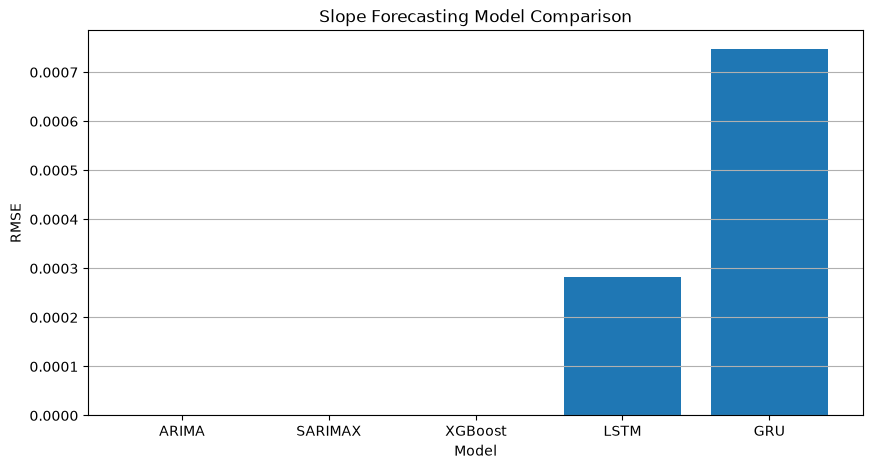

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.title(
    "Slope Forecasting Model Comparison"
)

plt.grid(
    axis="y"
)

plt.show()

In [40]:
# Get the best model based on Total_Rank

best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: ARIMA


In [42]:
if best_model_name == "ARIMA":

    final_prediction = float(
        arima_pred[-1]
    )

elif best_model_name == "SARIMAX":

    final_prediction = float(
        sarimax_pred[-1]
    )

elif best_model_name == "XGBoost":

    final_prediction = float(
        xgb_pred[-1]
    )

elif best_model_name == "LSTM":

    final_prediction = float(
        lstm_pred[-1]
    )

elif best_model_name == "GRU":

    final_prediction = float(
        gru_pred[-1]
    )

else:

    raise ValueError(
        "Unknown model"
    )

print(
    "Final predicted slope:",
    final_prediction,
    "degrees"
)

Final predicted slope: 35.28230268143529 degrees


In [43]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

results = results.sort_values(
    "Total_Rank"
).reset_index(drop=True)

best_model_name = results.loc[
    0, "Model"
]

print(
    "================================"
)

print(
    "BEST MODEL:",
    best_model_name
)

print(
    "================================"
)


# ==========================================
# FINAL PREDICTION
# ==========================================

if best_model_name == "ARIMA":

    final_prediction = float(
        arima_pred[-1]
    )

elif best_model_name == "SARIMAX":

    final_prediction = float(
        sarimax_pred[-1]
    )

elif best_model_name == "XGBoost":

    final_prediction = float(
        xgb_pred[-1]
    )

elif best_model_name == "LSTM":

    final_prediction = float(
        lstm_pred[-1]
    )

elif best_model_name == "GRU":

    final_prediction = float(
        gru_pred[-1]
    )

else:

    raise ValueError(
        "Unknown model selected!"
    )


print(
    "Final Prediction:",
    final_prediction,
    "degrees"
)

BEST MODEL: ARIMA
Final Prediction: 35.28230268143529 degrees


In [44]:
slope_min = df["slope_mean_degree"].min()
slope_max = df["slope_mean_degree"].max()


def slope_risk_score(
    slope,
    min_slope,
    max_slope
):

    # If all slope values are identical
    if max_slope == min_slope:
        return 0.0

    score = (
        slope - min_slope
    ) / (
        max_slope - min_slope
    )

    return float(
        np.clip(score, 0, 1)
    )


final_risk_score = slope_risk_score(
    final_prediction,
    slope_min,
    slope_max
)


def risk_level(score):

    if score < 0.2:
        return "LOW"

    elif score < 0.4:
        return "MODERATE"

    elif score < 0.6:
        return "HIGH"

    elif score < 0.8:
        return "VERY HIGH"

    else:
        return "EXTREME"


final_risk_level = risk_level(
    final_risk_score
)


print("Predicted Slope:",
      final_prediction)

print("Risk Score:",
      final_risk_score)

print("Risk Level:",
      final_risk_level)

Predicted Slope: 35.28230268143529
Risk Score: 0.0
Risk Level: LOW


In [45]:
slope_min = df[
    "slope_mean_degree"
].min()

slope_max = df[
    "slope_mean_degree"
].max()

print(
    "Minimum slope:",
    slope_min
)

print(
    "Maximum slope:",
    slope_max
)

Minimum slope: 35.28230268143529
Maximum slope: 35.28230268143529


In [46]:
def slope_risk_score(
    slope,
    min_slope,
    max_slope
):

    if max_slope == min_slope:

        return 0.0

    score = (
        slope - min_slope
    ) / (
        max_slope - min_slope
    )

    return float(
        np.clip(
            score,
            0,
            1
        )
    )

In [47]:
final_risk_score = slope_risk_score(
    final_prediction,
    slope_min,
    slope_max
)

print(
    "Slope risk score:",
    final_risk_score
)

Slope risk score: 0.0


In [48]:
def risk_level(score):

    if score < 0.2:
        return "LOW"

    elif score < 0.4:
        return "MODERATE"

    elif score < 0.6:
        return "HIGH"

    elif score < 0.8:
        return "VERY HIGH"

    else:
        return "EXTREME"

In [49]:
final_risk_level = risk_level(
    final_risk_score
)

print(
    "Slope risk level:",
    final_risk_level
)

Slope risk level: LOW


In [50]:
lstm_path = os.path.join(
    MODEL_DIR,
    "Slope_lstm.pt"
)

torch.save({

    "model_type": "LSTM",

    "input_size": 1,

    "hidden_size": 64,

    "num_layers": 2,

    "sequence_length":
        SEQUENCE_LENGTH,

    "model_state_dict":
        lstm_model.state_dict(),

    "metrics": {

        "MAE":
            float(lstm_metrics[0]),

        "RMSE":
            float(lstm_metrics[1]),

        "MAPE":
            float(lstm_metrics[2]),

        "R2":
            float(lstm_metrics[3])
    }

}, lstm_path)

print(
    "LSTM saved:",
    lstm_path
)

LSTM saved: E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_lstm.pt


In [51]:
gru_path = os.path.join(
    MODEL_DIR,
    "Slope_gru.pt"
)

torch.save({

    "model_type": "GRU",

    "input_size": 1,

    "hidden_size": 64,

    "num_layers": 2,

    "sequence_length":
        SEQUENCE_LENGTH,

    "model_state_dict":
        gru_model.state_dict(),

    "metrics": {

        "MAE":
            float(gru_metrics[0]),

        "RMSE":
            float(gru_metrics[1]),

        "MAPE":
            float(gru_metrics[2]),

        "R2":
            float(gru_metrics[3])
    }

}, gru_path)

print(
    "GRU saved:",
    gru_path
)

GRU saved: E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_gru.pt


In [52]:
if best_model_name == "ARIMA":

    best_model_path = os.path.join(
        MODEL_DIR,
        "Slope_best_model.pkl"
    )

    joblib.dump(
        arima_fit,
        best_model_path
    )

    print(
        "Best ARIMA model saved:"
    )

    print(
        best_model_path
    )

Best ARIMA model saved:
E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_best_model.pkl


In [53]:
scaler_path = os.path.join(
    MODEL_DIR,
    "Slope_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print(
    "Scaler saved:",
    scaler_path
)

Scaler saved: E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_scaler.pkl


In [54]:
metadata = {

    "dataset": "Slope",

    "best_model":
        best_model_name,

    "best_model_file":
        os.path.basename(
            best_model_path
        ),

    "sequence_length":
        SEQUENCE_LENGTH,

    "predicted_slope_degree":
        float(final_prediction),

    "slope_risk_score":
        float(final_risk_score),

    "slope_risk_level":
        final_risk_level,

    "metrics":
        results.to_dict(
            orient="records"
        )
}

metadata_path = os.path.join(
    MODEL_DIR,
    "Slope_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    "Metadata saved:",
    metadata_path
)

Metadata saved: E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_metadata.json


In [55]:
print("\nSaved Slope model files:\n")

for file in os.listdir(
    MODEL_DIR
):

    print(file)


Saved Slope model files:

Slope_best_model.pkl
Slope_gru.pt
Slope_lstm.pt
Slope_metadata.json
Slope_scaler.pkl


In [56]:
# ==============================
# SAVE XGBOOST MODEL
# ==============================

xgb_path = os.path.join(MODEL_DIR, "Slope_XGBoost.json")

xgb_model.save_model(xgb_path)

print("✅ XGBoost model saved successfully!")
print("📁 Path:", xgb_path)

✅ XGBoost model saved successfully!
📁 Path: E:\MY projects\Flash Flood Prediction Project\models\Slope\Slope_XGBoost.json


In [57]:
print("\nSaved Slope model files:\n")

for file in os.listdir(
    MODEL_DIR
):

    print(file)


Saved Slope model files:

Slope_best_model.pkl
Slope_gru.pt
Slope_lstm.pt
Slope_metadata.json
Slope_scaler.pkl
Slope_XGBoost.json
